In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from glob import glob
import os
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from keras import layers
from functools import partial
print('all assets functional')

AUTO =tf.data.experimental.AUTOTUNE
import warnings
warnings.filterwarnings('ignore')


all assets functional


In [15]:
metadata = pd.read_csv('HAM10000_metadata.csv')

images_1 = glob('HAM10000_images_part_1/*.jpg')
images_2 = glob('HAM10000_images_part_2/*.jpg')

# combine the two lists of images
images = images_1 + images_2

# build dataframe from filenames and merge diagnosis metadata
df = pd.DataFrame({'image_path': images})
df['image_id'] = df['image_path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
df = df.merge(metadata[['image_id', 'dx']], on='image_id', how='left')

# binary target label: malignant vs benign
malignant_labels = {'mel', 'bcc', 'akiec'}
df['label'] = df['dx'].apply(lambda x: 'malignant' if x in malignant_labels else 'benign')
df['binary_label'] = df['label'].apply(lambda x: 1 if x == 'malignant' else 0)

df[['image_path', 'dx', 'label', 'binary_label']].head()

,image_path,dx,label,binary_label
0,HAM10000_images_part_1\ISIC_0024306.jpg,nv,benign,0
1,HAM10000_images_part_1\ISIC_0024307.jpg,nv,benign,0
2,HAM10000_images_part_1\ISIC_0024308.jpg,nv,benign,0
3,HAM10000_images_part_1\ISIC_0024309.jpg,nv,benign,0
4,HAM10000_images_part_1\ISIC_0024310.jpg,mel,malignant,1


binary_label
0    8061
1    1954
Name: count, dtype: int64


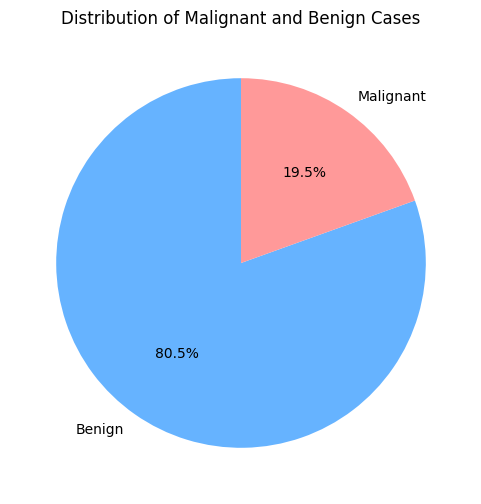

In [18]:
#counting the number of malignant and benign cases
counts = df['binary_label'].value_counts()
print(counts)

#plotting a pie chart to visualize the distribution of malignant and benign cases
plt.figure(figsize=(6, 6))
plt.pie(counts,
        labels=['Benign', 'Malignant'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#66b3ff','#ff9999'])
plt.title('Distribution of Malignant and Benign Cases')
plt.show()

In [22]:
#handling class imbalance by oversampling the minority class (malignant cases)
from imblearn.over_sampling import RandomOverSampler

# oversample rows instead of using SMOTE on string image paths
x = df[['image_path']]
y = df['binary_label']

oversampler = RandomOverSampler(random_state=42)

x_resampled, y_resampled = oversampler.fit_resample(x, y)
resampled_df = x_resampled.copy()
resampled_df['binary_label'] = y_resampled.values
resampled_df.head()



,image_path,binary_label
0,HAM10000_images_part_1\ISIC_0024306.jpg,0
1,HAM10000_images_part_1\ISIC_0024307.jpg,0
2,HAM10000_images_part_1\ISIC_0024308.jpg,0
3,HAM10000_images_part_1\ISIC_0024309.jpg,0
4,HAM10000_images_part_1\ISIC_0024310.jpg,1


binary_label
0    8061
1    8061
Name: count, dtype: int64


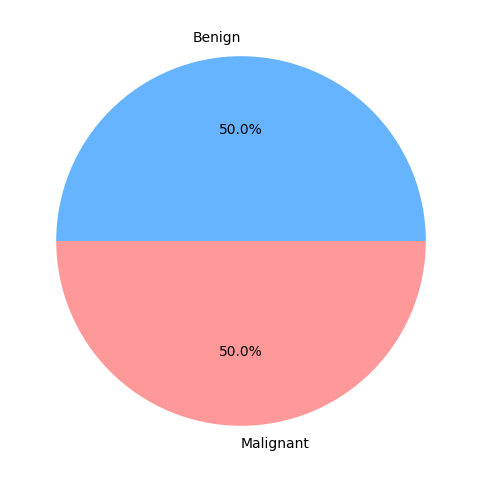

In [26]:
#now plotting a pie chartt
#for the resampled dataset
#value counts
counts = resampled_df['binary_label'].value_counts()
print(counts)

#pie
plt.figure(figsize=(6, 6))
plt.pie(counts,
        labels=['Benign', 'Malignant'],
        autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999']
        )
plt.show()


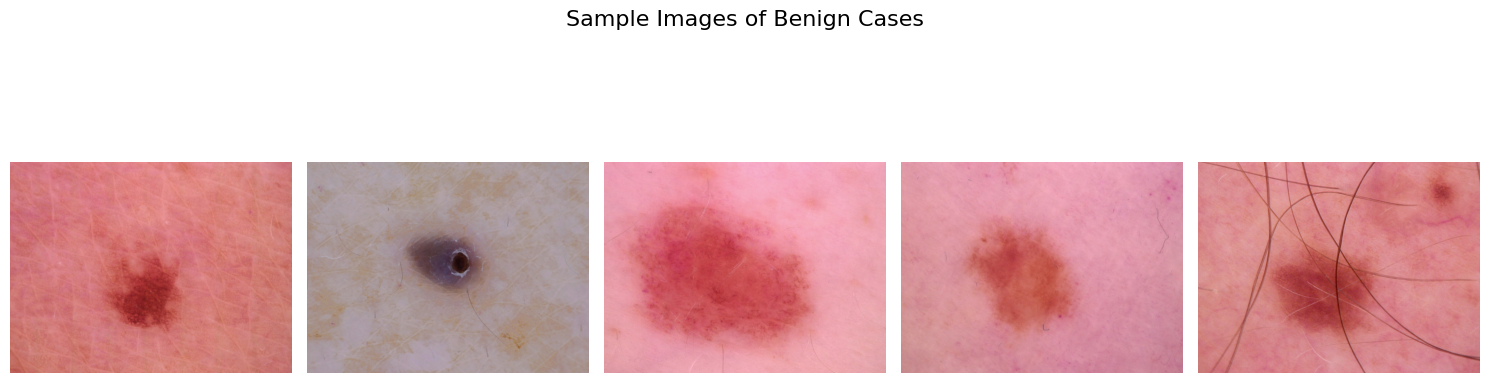

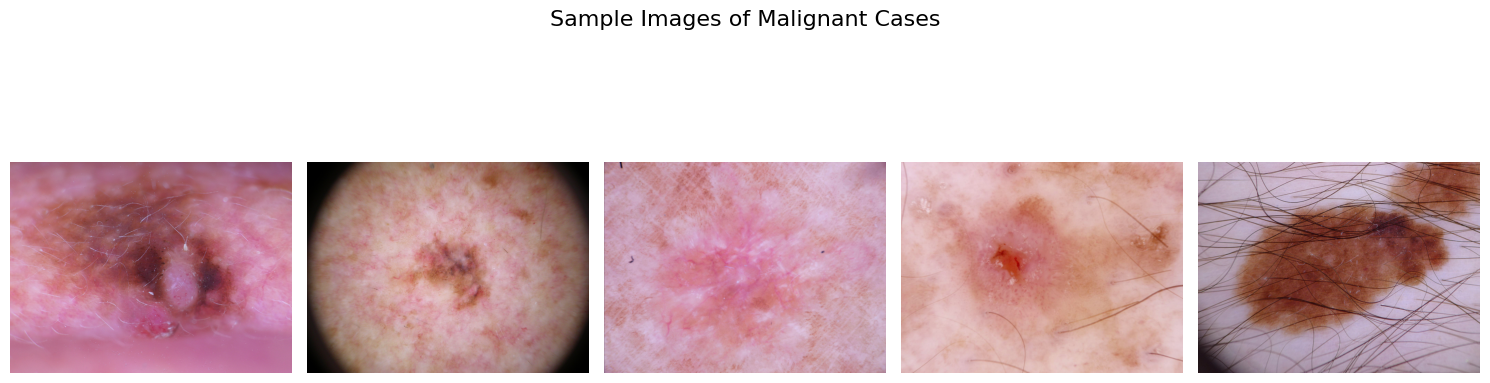

In [30]:
# previewing some images from the resampled dataset
for label_value, label_name in [(0, 'Benign'), (1, 'Malignant')]:
    temp = resampled_df[resampled_df['binary_label'] == label_value].sample(5, random_state=42)
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    fig.suptitle(f'Sample Images of {label_name} Cases', fontsize=16)

    for ax, (_, row) in zip(axes, temp.iterrows()):
        img = np.array(Image.open(row['image_path']))
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [32]:
features = df['image_path']
target = df['binary_label']

#train test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.15, random_state=42, stratify=target)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8512,), (1503,), (8512,), (1503,))

In [34]:
def decoding_img(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize_with_pad(img, 224, 224)
    img = tf.cast(img, tf.float32) / 255.0  # Normalize

    if label == 0:
        label = 0
    else:
        label = 1

    return img, label

#creating dataset
train_Ds = (
    tf.data.Dataset.from_tensor_slices((X_train.values, y_train.values))
    .map(decoding_img, num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

test_Ds = (
    tf.data.Dataset.from_tensor_slices((X_test.values, y_test.values))
    .map(decoding_img, num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

print('train dataset:', train_Ds)
print('test dataset:', test_Ds) 


train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [36]:
from tensorflow.keras.applications import EfficientNetB0
pre_trained_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    weights='imagenet',
    include_top=False
)

for layer in pre_trained_model.layers:
    layer.trainable = False


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step


In [47]:
from tensorflow.keras import Model

input = layers.Input(shape=(224, 224, 3))
x = layers.Flatten()(input)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs=input, outputs=outputs)

In [48]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics = ['AUC'])


In [ ]:
#fitting the model
history = model.fit(
    train_Ds,
    validation_data=test_Ds,
    epochs = 50,
    verbose = 1

)

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 97s 361ms/step - AUC: 0.8794 - loss: 0.3207 - val_AUC: 0.7437 - val_loss: 0.5072
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 92s 347ms/step - AUC: 0.8863 - loss: 0.3114 - val_AUC: 0.7037 - val_loss: 0.8720
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 93s 350ms/step - AUC: 0.8930 - loss: 0.3022 - val_AUC: 0.6910 - val_loss: 0.7368
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 94s 351ms/step - AUC: 0.8971 - loss: 0.2982 - val_AUC: 0.5958 - val_loss: 1.3642
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 92s 345ms/step - AUC: 0.9007 - loss: 0.2951 - val_AUC: 0.7278 - val_loss: 0.7233
Epoch 6/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 92s 344ms/step - AUC: 0.9118 - loss: 0.2793 - val_AUC: 0.5409 - val_loss: 2.3394
Epoch 7/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 92s 345ms/step - AUC: 0.9175 - loss: 0.2697 - val_AUC: 0.5110 - val_loss: 4.2725
Epoch 8/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 92s 344ms/step - AUC: 0.9222 - loss: 0.2630 - val_AUC: 0.5394 - val_loss: 2.2642
Epoch 9/50
266/266 ━━━━━━━━━━━━━

In [50]:
hist_df = pd.DataFrame(history.history)
hist_df.head()

,AUC,loss,val_AUC,val_loss
0,0.674171,0.528083,0.768082,0.417691
1,0.766559,0.427543,0.707655,0.770914
2,0.780074,0.412558,0.815227,0.392649
3,0.801118,0.395921,0.762232,0.433409
4,0.807741,0.389830,0.681140,0.459382


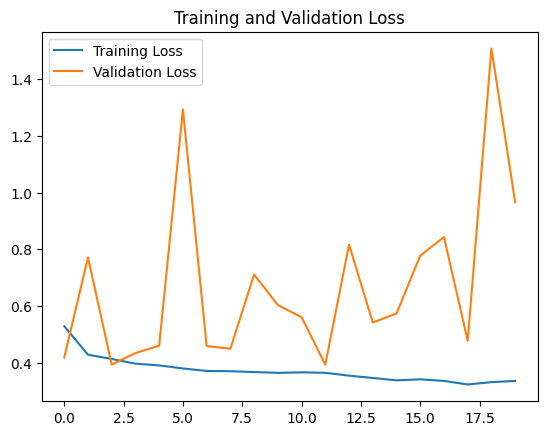

In [53]:
hist_df['loss'].plot()
hist_df['val_loss'].plot()
plt.title('Training and Validation Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

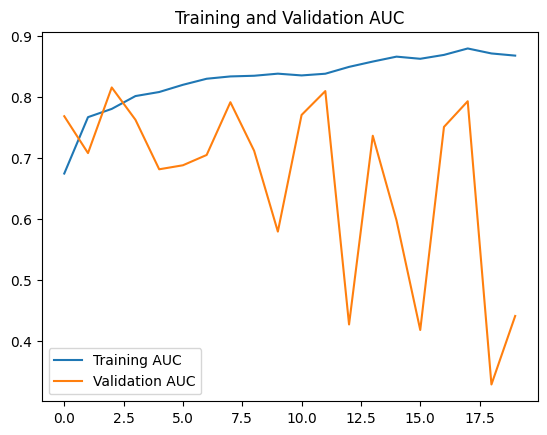

In [54]:
#plotting the auc
hist_df['AUC'].plot()
hist_df['val_AUC'].plot()
plt.title('Training and Validation AUC')
plt.legend(['Training AUC', 'Validation AUC'])
plt.show()


In [55]:
#calc the accuracy
#since its a binary classification
from sklearn.metrics import accuracy_score

predictions = model.predict(test_Ds)

#calc accuracy
accuracy_score(y_test, (predictions > 0.5).astype(int))
print(f"Accuracy on test set: {accuracy_score(y_test, (predictions > 0.5).astype(int)) * 100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step
Accuracy on test set: 59.35%
